# Retrieve and plot sea ice concentration
This notebook demonstrates how to download daily mean values of sea ice concentration for two dates.
This example uses the native grib2 format of CARRA2

## Load dependencies and create folders
In the first cell we load the relevant libraries for this notebook

In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi
import cfgrib
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr

In [2]:
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

## Download fields
In the section below, fields are downloaded and stored

In [ ]:
target_path = os.path.join('data', 'sea_ice_area_fraction.grib')

dataset = "reanalysis-pan-carra-means"
request = {
    "time_aggregation": "daily",
    "level_type": "single_levels",
    "variable": ["sea_ice_area_fraction"],
    "product_type": "analysis_based",
    "year": ["2025"],
    "month": ["03", "09"],
    "day": ["21"],
    "data_format": "grib"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(target_path)

## Load and inspect dataset
Having downloaded the selected dates as a grib2 file, we can now open it as an `xarray` dataset using `cfgrib`

In [4]:
ds = xr.open_dataset(target_path, engine='cfgrib')
ds

<xarray.Dataset> Size: 199MB
Dimensions:     (time: 2, y: 2880, x: 2880)
Coordinates:
  * time        (time) datetime64[ns] 16B 2025-03-21 2025-09-21
    valid_time  (time) datetime64[ns] 16B ...
    latitude    (y, x) float64 66MB ...
    longitude   (y, x) float64 66MB ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    siconc      (time, y, x) float32 66MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             enmi
    GRIB_centreDescription:  Oslo
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Oslo
    history:                 2026-06-09T13:21 GRIB to CDM+CF via cfgrib-0.9.1...

## Plot snapshots of sea ice minimum and maximum
Upon inspection, we can now plot the sea ice cover for the two dates.
We define a circular boundary for aesthetics.

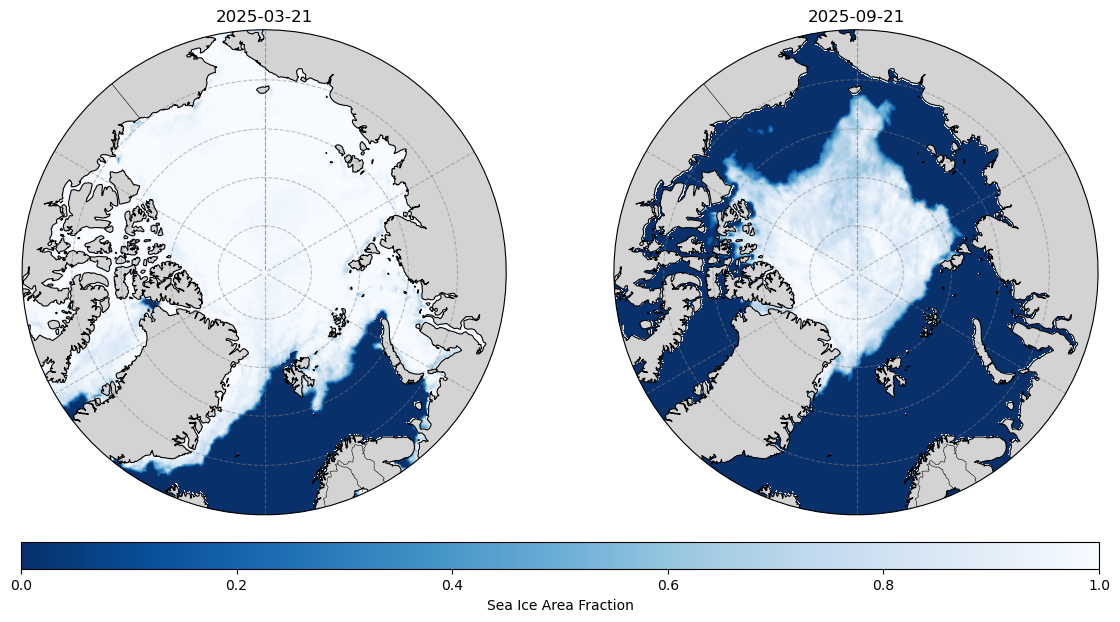

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.NorthPolarStereo()})
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for i, ax in enumerate(axes):
    data_slice = ds['siconc'].isel(time=i)
    
    ax.set_extent([-180, 180, 65, 90], crs=ccrs.PlateCarree())
    
    im = data_slice.plot.pcolormesh(
        ax=ax,
        x='longitude',
        y='latitude',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        cmap='Blues_r',
        vmin=0, vmax=1,
        zorder=1
    )
    
    ax.add_feature(cfeature.LAND,facecolor='lightgray',  zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)
    ax.gridlines(linestyle='--', color='gray', alpha=0.5, zorder=4)
    
    ax.set_boundary(circle, transform=ax.transAxes)
    date_str = str(data_slice.time.values)[:10]
    ax.set_title(f"{date_str}")

cbar = plt.colorbar(im, ax=axes, orientation='horizontal', pad=0.05, fraction=0.05, aspect=40)
cbar.set_label('Sea Ice Area Fraction')

plt.show()